## Notebook Goal:
* Register all MRIs to a common atlas space `SRI24` using a rigid transformation (linear transformation only).

* The transformation is computed between the atlas template and each MRI volume. The same transformation is then applied to the segmentation masks to preserve the true anatomical overlap.

* This step is important because the mask autoencoder was trained in a unified spatial space. Aligning the fine-tuning dataset to the same atlas space helps the model better segmentation task and improves consistency during training.

In [1]:
import os
import nibabel as nib
import numpy as np
from nibabel.orientations import aff2axcodes
from nibabel.orientations import axcodes2ornt, ornt_transform, inv_ornt_aff
import matplotlib.pyplot as plt
import ants
import napari
import shutil
import pandas as pd

**Starting by an example to validate**

**Mri**

(512, 512, 40)
voxel spacing:  (0.5, 0.5, 1.9999926)
image orentation:  ('L', 'P', 'S')


(-0.5, 511.5, 511.5, -0.5)

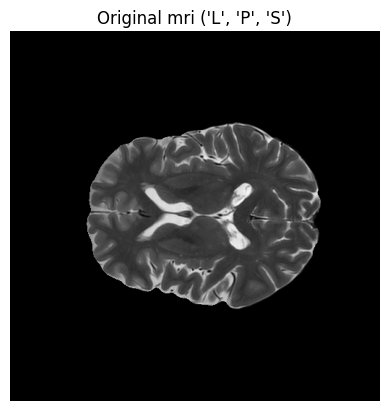

In [2]:
mri = nib.load('T2_MRIs_Normalized/High_Resolution/P010SBN.nii.gz')
print(mri.shape)
# print the spacing between voxels
print("voxel spacing: ", mri.header.get_zooms())

print("image orentation: ", aff2axcodes(mri.affine))
# show mid slice axial
plt.imshow(mri.get_fdata()[:, :, mri.shape[2] // 2], cmap='gray')
plt.title(f'Original mri {aff2axcodes(mri.affine)}')
plt.axis('off')

**Mask**

(512, 512, 40)
voxel spacing:  (0.5, 0.5, 1.9999926)
image orentation:  ('R', 'A', 'S')


(-0.5, 511.5, 511.5, -0.5)

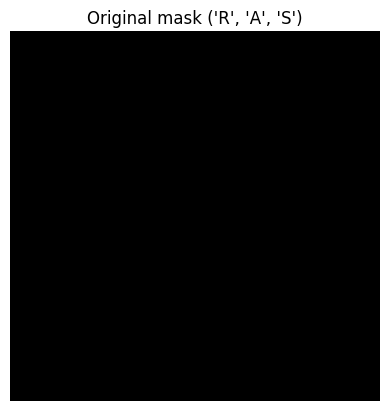

In [3]:
mask = nib.load('distal_segmentation/STN/High_Resolution/STN_mask_P010.nii')
print(mask.shape)
# print the spacing between voxels
print("voxel spacing: ", mask.header.get_zooms())

print("image orentation: ", aff2axcodes(mask.affine))
# show mid slice axial
plt.imshow(mask.get_fdata()[:, :, mask.shape[2] // 2], cmap='gray')
plt.title(f'Original mask {aff2axcodes(mask.affine)}')
plt.axis('off')

(240, 240, 155, 1)
voxel spacing:  (1.0, 1.0, 1.0, 0.0)
image orentation:  ('R', 'A', 'S')


(-0.5, 239.5, 239.5, -0.5)

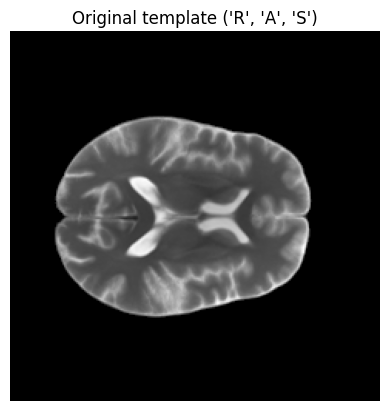

In [4]:
template = nib.load('SRI24/T2_brain.nii')
print(template.shape)
print("voxel spacing: ", template.header.get_zooms())
print("image orentation: ", aff2axcodes(template.affine))
plt.imshow(template.get_fdata()[:, :, template.shape[2] // 2], cmap='gray')
plt.title(f'Original template {aff2axcodes(template.affine)}')
plt.axis('off')

* `One thing we notice` is that after we done many expirment of registration the mri to the atlas space (template) and do the same transformation to the mask the result was not overlapped, meaning the stn mask indicate stn in non anatomical stn region and this is due to miss orientation
* After detailed examination we found that the problem is in the affine matrix of the mask was multiplied by negative unit scalar(-1)

In [5]:
print("MRI affine:\n", mri.affine)
print("Mask affine:\n", mask.affine)

print("Affine difference:", np.abs(mri.affine - mask.affine).max())

MRI affine:
 [[-4.98821795e-01 -1.80399194e-02  1.16711870e-01  1.31376999e+02]
 [ 6.21864852e-03 -4.65787053e-01 -7.26674855e-01  1.42352997e+02]
 [ 3.37361395e-02 -1.80878401e-01  1.85964847e+00  7.44216003e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Mask affine:
 [[ 4.98821795e-01  1.80399194e-02 -1.16711870e-01 -1.31376999e+02]
 [-6.21864805e-03  4.65787053e-01  7.26674855e-01 -1.42352997e+02]
 [ 3.37361395e-02 -1.80878401e-01  1.85964847e+00  7.44216003e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Affine difference: 284.70599365234375


* `Esiest solution` since the Mask and the Mri in **Native space** overlaped correclty that means they should share same affine matrix and therfore we just copy the affine matrix of the MRI to the Mask to make sure affine transformation are indentical in both on Registration

In [6]:
mri   = ants.image_read("T2_MRIs_Normalized/High_Resolution/P010SBN.nii.gz")
mask  = ants.image_read("distal_segmentation/STN/High_Resolution/STN_mask_P010.nii")

# force identical geometry
mask = ants.copy_image_info(mri, mask)

* Helper Functions

In [7]:
def reorient_to_ras(nib_img):
    """Reorient a nibabel image to RAS+ orientation."""
    orig_ornt = nib.io_orientation(nib_img.affine)
    ras_ornt = axcodes2ornt(('R', 'A', 'S'))
    transform = ornt_transform(orig_ornt, ras_ornt)
    reoriented = nib_img.as_reoriented(transform)
    return reoriented

def reorient_to_lps(nib_img):
    """Reorient a nibabel image to LPS+ orientation."""
    orig_ornt = nib.io_orientation(nib_img.affine)
    lps_ornt = axcodes2ornt(('L', 'P', 'S'))
    transform = ornt_transform(orig_ornt, lps_ornt)
    reoriented = nib_img.as_reoriented(transform)
    return reoriented

* **Start Registration**
    * `registration`: function that does registration of mri and mask to atlas space

    * `calculate_dice_score`: function that calculates the dice score between the native (original) mask and the reveresed mask(from registered space to native sapce)

    * `reverse_mask`: function that does the reverse transformation (from registered space to native sapce)
    
    * `eyeup`: function that unify the oreintation of both the mask and mri to LPS

In [8]:
def registration(mri_path, mask_path, atlas_path):
    

    atlas = ants.image_read(atlas_path)
    mri   = ants.image_read(mri_path)
    mask  = ants.image_read(mask_path)

    # force identical geometry
    mask = ants.copy_image_info(mri, mask)

 
    # registration
    tx = ants.registration(
        fixed=atlas,
        moving=mri,
        type_of_transform="Affine"
    )

    # apply to MRI
    mri_reg = ants.apply_transforms(
        fixed=atlas,
        moving=mri,
        transformlist=tx['fwdtransforms'],
        interpolator="linear"
    )

    # apply to mask
    mask_reg = ants.apply_transforms(
        fixed=atlas,
        moving=mask,
        transformlist=tx['fwdtransforms'],
        interpolator="genericLabel"   # better of for masks
    )
    print("forward", tx['fwdtransforms'])
    print("backward", tx['invtransforms'])

    os.makedirs("transforms", exist_ok=True)
    os.makedirs("registered", exist_ok=True)

    resolution = os.path.basename(os.path.dirname(mri_path))
    subject_id = os.path.basename(mri_path).split(".")[0]

    # mri output dir is registered/mris/resolution
    mri_out_dir = os.path.join("registered", "mris", resolution)

    # mask output dir is registered/masks/resolution
    mask_out_dir = os.path.join("registered", "masks", resolution)

    transform_dir = os.path.join("transforms", resolution)

    os.makedirs(mri_out_dir, exist_ok=True)
    os.makedirs(mask_out_dir, exist_ok=True)
    os.makedirs(transform_dir, exist_ok=True)

    # save
    ants.image_write(mri_reg, os.path.join(mri_out_dir, f"{subject_id}_registered.nii.gz"))
    ants.image_write(mask_reg, os.path.join(mask_out_dir, f"{subject_id}_registered_mask.nii.gz"))

    for i, t in enumerate(tx["fwdtransforms"]):
        # save with subject id
        shutil.copy(t, os.path.join(transform_dir, f"{subject_id}_fwd_{i}.mat"))

    for i, t in enumerate(tx["invtransforms"]):
        shutil.copy(t, os.path.join(transform_dir, f"{subject_id}_inv_{i}.mat"))

In [9]:
def calculate_dice_score(mask_original, mask_back):

    mask_original_np = mask_original.numpy() > 0
    mask_back_np   = mask_back.numpy() > 0

    intersection = np.logical_and(mask_original_np, mask_back_np).sum()
    dice = 2 * intersection / (mask_original_np.sum() + mask_back_np.sum())

    return dice


In [10]:
def reverse_mask(regsitered_mask_path, native_mri_path, orginal_mask_path, dice_df_path):
    registered_mask = ants.image_read(regsitered_mask_path)
    native_mri = ants.image_read(native_mri_path)
    original_mask = ants.image_read(orginal_mask_path)

    # find the corresponding forward transform
    subject_id = os.path.basename(native_mri_path).split(".")[0]
    resolution = os.path.basename(os.path.dirname(native_mri_path))
    transform_dir = os.path.join("transforms", resolution)
    fwd_transform_path = os.path.join(transform_dir, f"{subject_id}_fwd_0.mat")

    # apply inverse transform to mask
    mask_native = ants.apply_transforms(
        fixed=native_mri,
        moving=registered_mask,
        transformlist=[fwd_transform_path],
        interpolator="genericLabel",
        whichtoinvert=[True],
    )
    # calculate dice score
    dice = calculate_dice_score(original_mask, mask_native)
    print(f"Dice score for {subject_id}: {dice:.4f}")

    # add it to a global dataframe
    output_dir = os.path.join("reversed_masks", resolution)
    os.makedirs(output_dir, exist_ok=True)
    # save the dice score to a csv file in revesred_masks folder
    dice_df_path = os.path.join("reversed_masks", dice_df_path)
    if os.path.exists(dice_df_path):
        dice_df = pd.read_csv(dice_df_path)
    else:
        dice_df = pd.DataFrame(columns=["subject_id", "dice_score"])
    dice_df.loc[len(dice_df)] = [subject_id, dice]
    dice_df.to_csv(dice_df_path, index=False)
    
    # save the reversed mask
    ants.image_write(mask_native, os.path.join(output_dir, f"{subject_id}_reversed_mask.nii.gz"))

In [11]:
def eyeup(registered_mri_path, registered_mask_path):
    mri = nib.load(registered_mri_path)
    mask = nib.load(registered_mask_path)

    mri = reorient_to_lps(mri)
    mask = reorient_to_lps(mask)

    # save them in the same path
    nib.save(mri, registered_mri_path)
    nib.save(mask, registered_mask_path)

* Registration

In [63]:
# Registration example
atlas = "SRI24/T2_brain.nii"
mri   = "T2_MRIs_Normalized/High_Resolution/P010SBN.nii.gz"
mask  = "distal_segmentation/STN/High_Resolution/STN_mask_P010.nii"
registration(mri, mask, atlas)


forward ['/tmp/tmp3eyb27rp0GenericAffine.mat']
backward ['/tmp/tmp3eyb27rp0GenericAffine.mat']


In [64]:
registered_mri_path = "registered/mris/High_Resolution/P010SBN_registered.nii.gz"
registered_mask_path = "registered/masks/High_Resolution/P010SBN_registered_mask.nii.gz"

mri_reg_nib = nib.load(registered_mri_path)
print("Registered MRI shape: ", mri_reg_nib.shape)
print("Registered MRI spacing: ", mri_reg_nib.header.get_zooms())
print("Registered MRI orientation: ", aff2axcodes(mri_reg_nib.affine))
mask_reg_nib = nib.load(registered_mask_path)
print("Registered Mask shape: ", mask_reg_nib.shape)
print("Registered Mask spacing: ", mask_reg_nib.header.get_zooms())
print("Registered Mask orientation: ", aff2axcodes(mask_reg_nib.affine))
atlas_nib = nib.load(atlas)
print("Atlas shape: ", atlas_nib.shape)
print("Atlas spacing: ", atlas_nib.header.get_zooms())
print("Atlas orientation: ", aff2axcodes(atlas_nib.affine))


Registered MRI shape:  (240, 240, 155)
Registered MRI spacing:  (1.0, 1.0, 1.0)
Registered MRI orientation:  ('R', 'A', 'S')
Registered Mask shape:  (240, 240, 155)
Registered Mask spacing:  (1.0, 1.0, 1.0)
Registered Mask orientation:  ('R', 'A', 'S')
Atlas shape:  (240, 240, 155, 1)
Atlas spacing:  (1.0, 1.0, 1.0, 0.0)
Atlas orientation:  ('R', 'A', 'S')


* `Run this if you want to visualize all slices`

In [ ]:

viewer = napari.Viewer()

viewer.add_image(mri_reg_nib.get_fdata(), name="Registered MRI")
viewer.add_labels(mask_reg_nib.get_fdata().astype(int), name="STN Mask")

napari.run()

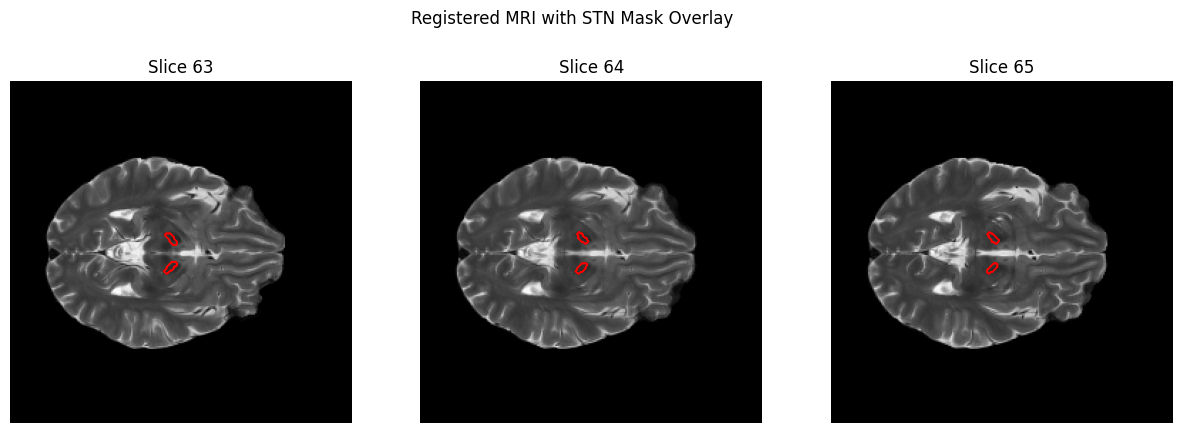

In [65]:
# Display 3 axial slices of the registered MRI and mask overlaying (63, 64, 65)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
slice_indices = [63, 64, 65]
for i, idx in enumerate(slice_indices):
    axes[i].imshow(mri_reg_nib.get_fdata()[:, :, idx], cmap='gray')
    axes[i].contour(mask_reg_nib.get_fdata()[:, :, idx], colors='r', linewidths=0.5)
    axes[i].set_title(f'Slice {idx}')
    axes[i].axis('off')
plt.suptitle('Registered MRI with STN Mask Overlay')
plt.show()



* Fix The oreintation

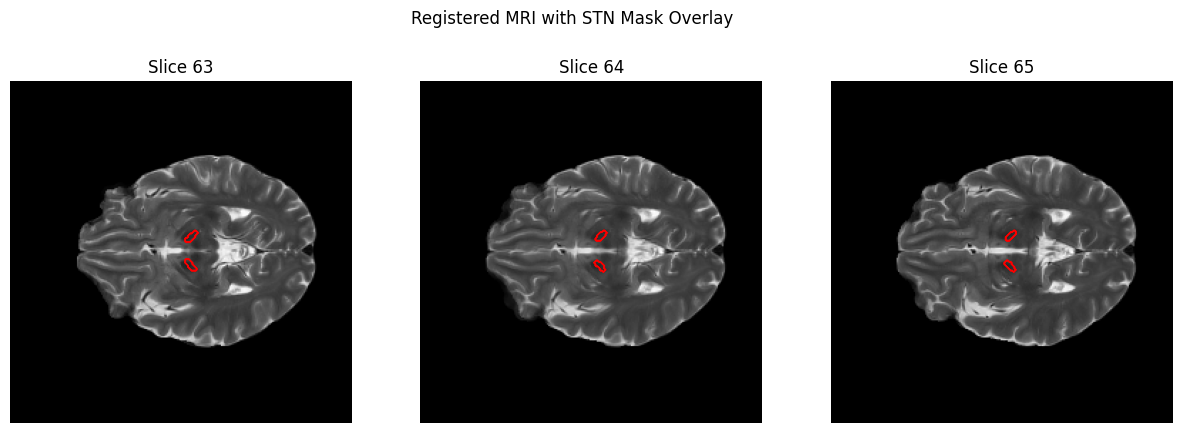

In [66]:
# make the oreintation LPS for eyeup
eyeup(registered_mri_path, registered_mask_path)
mri_reg_nib = nib.load(registered_mri_path)
mask_reg_nib = nib.load(registered_mask_path)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
slice_indices = [63, 64, 65]
for i, idx in enumerate(slice_indices):
    axes[i].imshow(mri_reg_nib.get_fdata()[:, :, idx], cmap='gray')
    axes[i].contour(mask_reg_nib.get_fdata()[:, :, idx], colors='r', linewidths=0.5)
    axes[i].set_title(f'Slice {idx}')
    axes[i].axis('off')
plt.suptitle('Registered MRI with STN Mask Overlay')
plt.show()



* Revrese Registration

In [72]:
# Reverse the mask back to native space and calculate dice score
original_mask_path = "distal_segmentation/STN/High_Resolution/STN_mask_P010.nii"
dice_df_path = "dice_scores.csv"
reverse_mask(registered_mask_path, mri, original_mask_path, dice_df_path)


Dice score for P010SBN: 0.9350


In [75]:

reverse_mask = "reversed_masks/High_Resolution/P010SBN_reversed_mask.nii.gz"
mri_nib = nib.load(mri)
reverse_mask_nib = nib.load(reverse_mask)
original_mask_nib = nib.load(original_mask_path)

print("Original MRI shape: ", mri_nib.shape)
print("Original MRI spacing: ", mri_nib.header.get_zooms())
print("Original MRI orientation: ", aff2axcodes(mri_nib.affine))
print("Original Mask shape: ", original_mask_nib.shape)
print("Original Mask spacing: ", original_mask_nib.header.get_zooms())
print("Original Mask orientation: ", aff2axcodes(original_mask_nib.affine))
print("Reversed Mask shape: ", reverse_mask_nib.shape)
print("Reversed Mask spacing: ", reverse_mask_nib.header.get_zooms())
print("Reversed Mask orientation: ", aff2axcodes(reverse_mask_nib.affine))



Original MRI shape:  (512, 512, 40)
Original MRI spacing:  (0.5, 0.5, 1.9999926)
Original MRI orientation:  ('L', 'P', 'S')
Original Mask shape:  (512, 512, 40)
Original Mask spacing:  (0.5, 0.5, 1.9999926)
Original Mask orientation:  ('R', 'A', 'S')
Reversed Mask shape:  (512, 512, 40)
Reversed Mask spacing:  (0.5, 0.5, 1.9999926)
Reversed Mask orientation:  ('L', 'P', 'S')


/tmp/ipykernel_75975/3762296965.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_75975/3762296965.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()
/tmp/ipykernel_75975/3762296965.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig3.show()


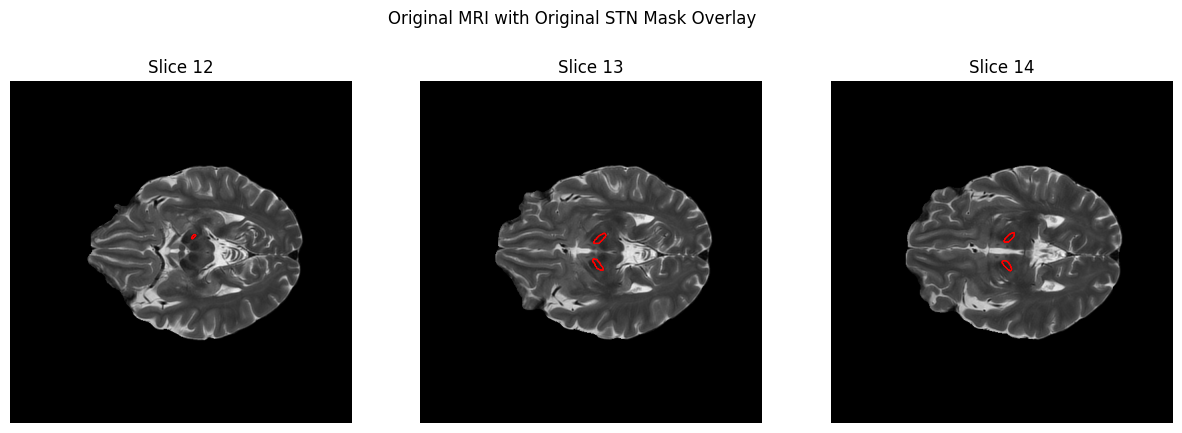

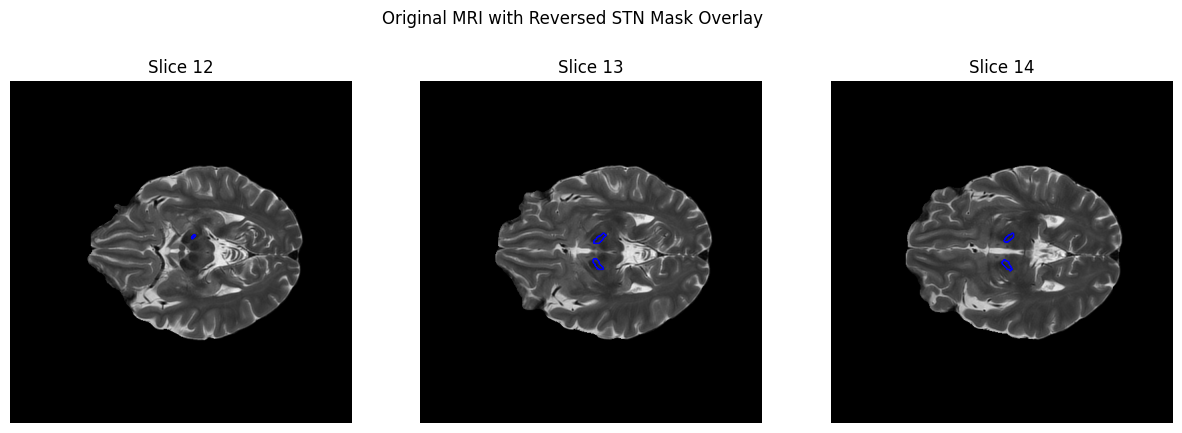

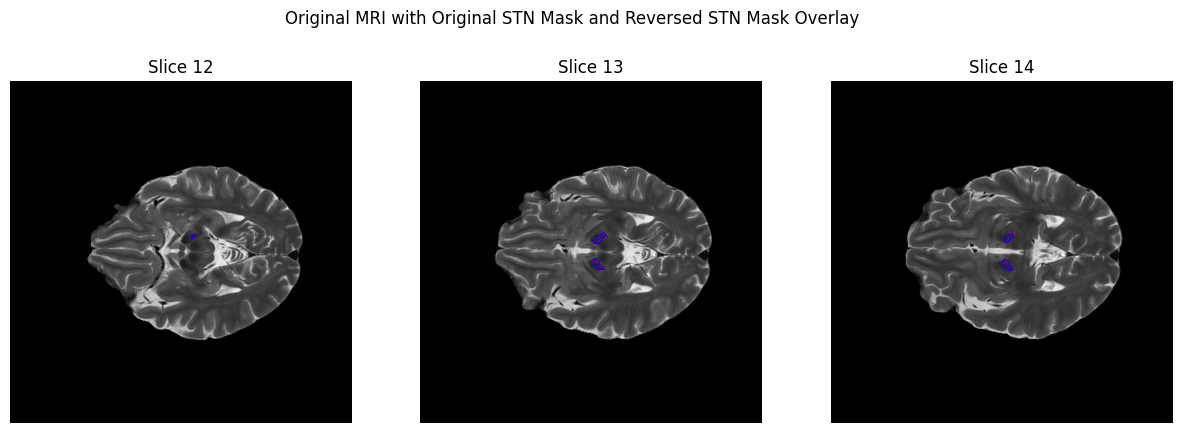

In [85]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
fig3, axes3 = plt.subplots(1, 3, figsize=(15, 5))
slice_indices = [12, 13, 14]
for i, idx in enumerate(slice_indices):
    axes[i].imshow(mri_nib.get_fdata()[:, :, idx], cmap='gray')
    axes[i].contour(original_mask_nib.get_fdata()[:, :, idx], colors='r', linewidths=0.5)
    axes[i].set_title(f'Slice {idx}')
    axes[i].axis('off')
fig.suptitle('Original MRI with Original STN Mask Overlay')
fig.show()
for i, idx in enumerate(slice_indices):
    axes2[i].imshow(mri_nib.get_fdata()[:, :, idx], cmap='gray')
    axes2[i].contour(reverse_mask_nib.get_fdata()[:, :, idx], colors='b', linewidths=0.5)
    axes2[i].set_title(f'Slice {idx}')
    axes2[i].axis('off')
fig2.suptitle('Original MRI with Reversed STN Mask Overlay')
fig2.show()

for i, idx in enumerate(slice_indices):
    axes3[i].imshow(mri_nib.get_fdata()[:, :, idx], cmap='gray')
    axes3[i].contour(original_mask_nib.get_fdata()[:, :, idx], colors='r', linewidths=0.5)
    axes3[i].contour(reverse_mask_nib.get_fdata()[:, :, idx], colors='b', linewidths=0.5, linestyles='dashed')
    axes3[i].set_title(f'Slice {idx}')
    axes3[i].axis('off')
fig3.suptitle('Original MRI with Original STN Mask and Reversed STN Mask Overlay')
fig3.show()


### For All Normalized MRIs

In [12]:
# do for all normlaized MRIs and masks for both high and low resoultion
atlas = "SRI24/T2_brain.nii"
normalized_mri_dir = "T2_MRIs_Normalized"
mask_dir = "distal_segmentation/STN"
for resolution in ["High_Resolution", "Low_Resolution"]:
    mri_dir = os.path.join(normalized_mri_dir, resolution)
    mask_dir_res = os.path.join(mask_dir, resolution)
    for mri_file in os.listdir(mri_dir):
        if mri_file.endswith(".nii.gz"):
            subject_id = mri_file.split(".")[0]
            subject_id_mask = subject_id.replace("SBN", "")
            mri_path = os.path.join(mri_dir, mri_file)
            mask_path = os.path.join(mask_dir_res, f"STN_mask_{subject_id_mask}.nii")
            if os.path.exists(mask_path):
                registration(mri_path, mask_path, atlas)
                registered_mri_path = os.path.join("registered", "mris", resolution, f"{subject_id}_registered.nii.gz")
                registered_mask_path = os.path.join("registered", "masks", resolution, f"{subject_id}_registered_mask.nii.gz")
                eyeup(registered_mri_path, registered_mask_path)
                reverse_mask(registered_mask_path, mri_path, mask_path, f"dice_scores_{resolution}.csv")
            else:
                print(f"Mask not found for {subject_id} at {mask_path}")

forward ['/tmp/tmpbc4jgdwv0GenericAffine.mat']
backward ['/tmp/tmpbc4jgdwv0GenericAffine.mat']
Dice score for P016SBN: 0.9252
forward ['/tmp/tmp9d35g6m70GenericAffine.mat']
backward ['/tmp/tmp9d35g6m70GenericAffine.mat']
Dice score for P021SBN: 0.9426
forward ['/tmp/tmp3n_0ncn60GenericAffine.mat']
backward ['/tmp/tmp3n_0ncn60GenericAffine.mat']
Dice score for P011SBN: 0.9416
forward ['/tmp/tmpl89itk6u0GenericAffine.mat']
backward ['/tmp/tmpl89itk6u0GenericAffine.mat']
Dice score for P042SBN: 0.9344
forward ['/tmp/tmpkojjvwad0GenericAffine.mat']
backward ['/tmp/tmpkojjvwad0GenericAffine.mat']
Dice score for P037SBN: 0.9349
forward ['/tmp/tmpii_z5mt00GenericAffine.mat']
backward ['/tmp/tmpii_z5mt00GenericAffine.mat']
Dice score for P045SBN: 0.9210
forward ['/tmp/tmpw9n5h_gy0GenericAffine.mat']
backward ['/tmp/tmpw9n5h_gy0GenericAffine.mat']
Dice score for P047SBN: 0.8983
forward ['/tmp/tmpws39f14i0GenericAffine.mat']
backward ['/tmp/tmpws39f14i0GenericAffine.mat']
Dice score for P043SBN:

#### MEAN and STN of Dice Scores

In [13]:
# calculate average dice score and std for each resolution
for resolution in ["High_Resolution", "Low_Resolution"]:
    dice_df_path = os.path.join("reversed_masks", f"dice_scores_{resolution}.csv")
    if os.path.exists(dice_df_path):
        dice_df = pd.read_csv(dice_df_path)
        avg_dice = dice_df["dice_score"].mean()
        std_dice = dice_df["dice_score"].std()
        print(f"{resolution} - Average Dice Score: {avg_dice:.4f}, Std Dev: {std_dice:.4f}")
    else:
        print(f"No dice scores found for {resolution} at {dice_df_path}")

High_Resolution - Average Dice Score: 0.9289, Std Dev: 0.0111
Low_Resolution - Average Dice Score: 0.9592, Std Dev: 0.0221


### Visualization

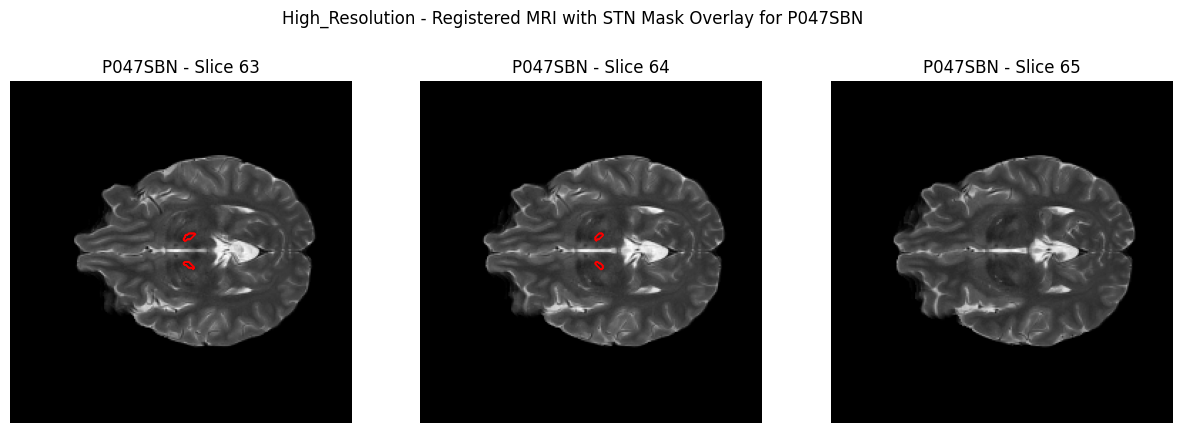

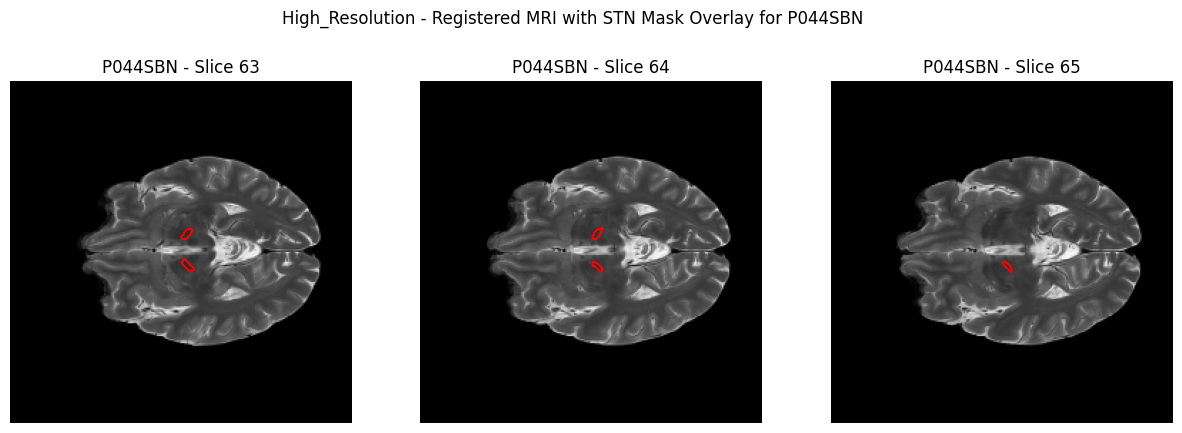

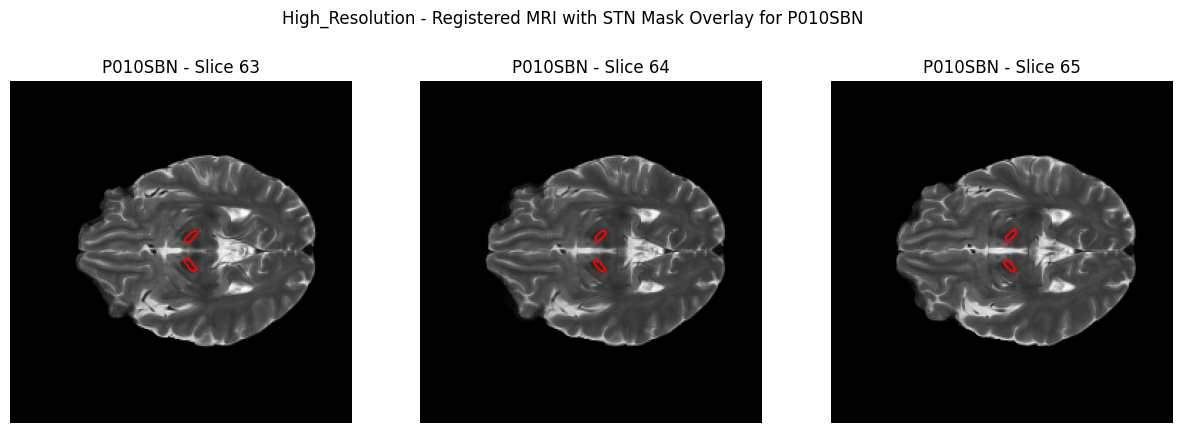

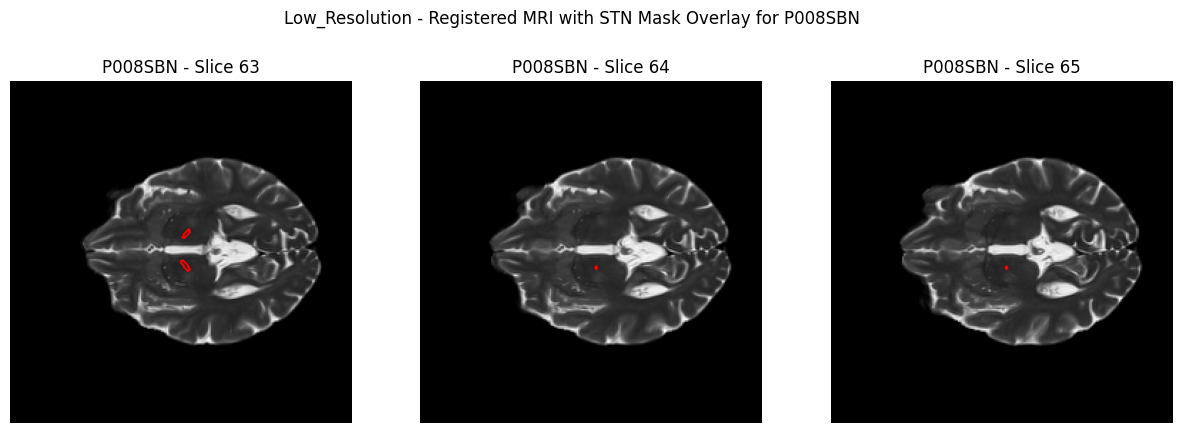

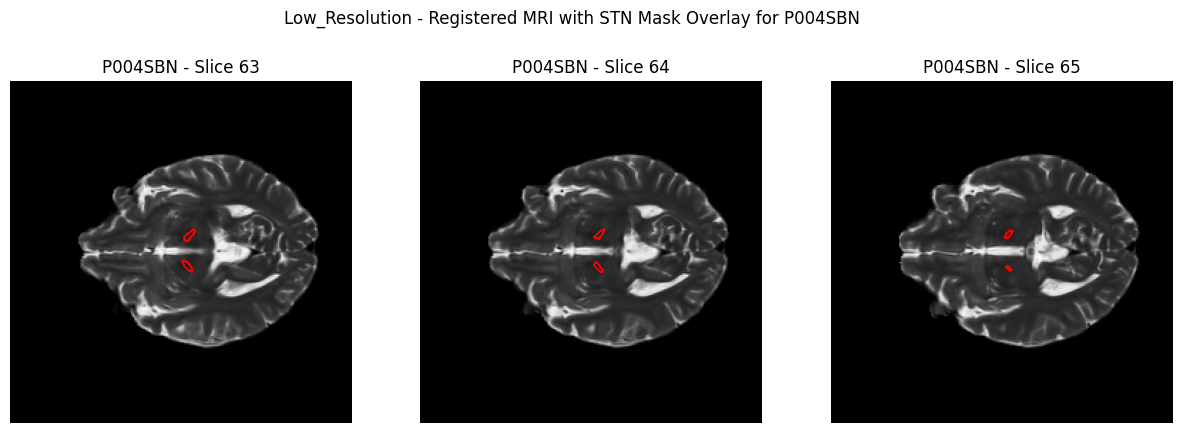

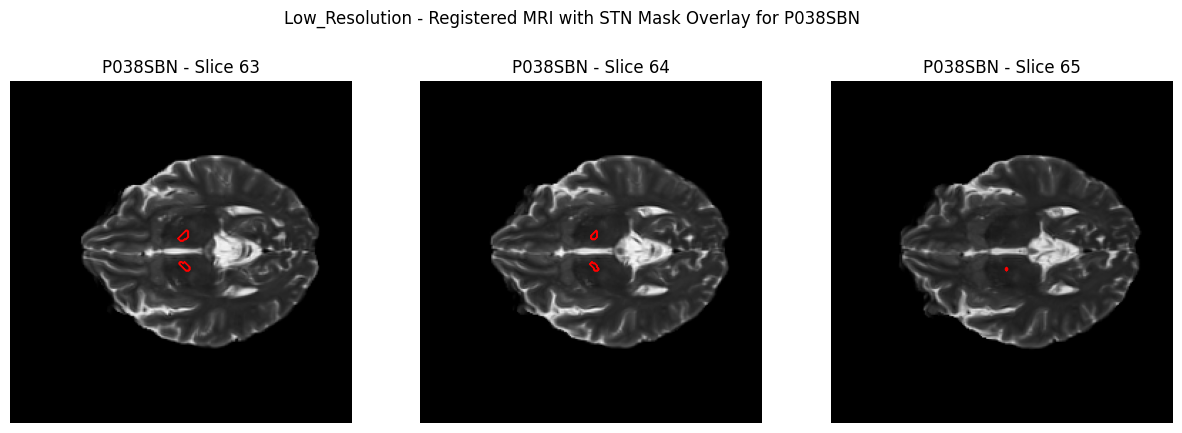

In [14]:
# viuslize 3 random subjects for each resolution with registered MRI, registered mask
for resolution in ["High_Resolution", "Low_Resolution"]:
    mri_dir = os.path.join("registered", "mris", resolution)
    mask_dir = os.path.join("registered", "masks", resolution)
    mri_files = [f for f in os.listdir(mri_dir) if f.endswith(".nii.gz")]
    mask_files = [f for f in os.listdir(mask_dir) if f.endswith(".nii.gz")]
    random_subjects = np.random.choice(mri_files, size=3, replace=False)
    for subject in random_subjects:
        subject_id = subject.split("_")[0]
        mri_path = os.path.join(mri_dir, subject)
        mask_path = os.path.join(mask_dir, f"{subject_id}_registered_mask.nii.gz")
        mri_nib = nib.load(mri_path)
        mask_nib = nib.load(mask_path)
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        slice_indices = [63, 64, 65]
        for i, idx in enumerate(slice_indices):
            axes[i].imshow(mri_nib.get_fdata()[:, :, idx], cmap='gray')
            axes[i].contour(mask_nib.get_fdata()[:, :, idx], colors='r', linewidths=0.5)
            axes[i].set_title(f'{subject_id} - Slice {idx}')
            axes[i].axis('off')
        plt.suptitle(f'{resolution} - Registered MRI with STN Mask Overlay for {subject_id}')
        plt.show()

### The Outputed Schema

```
registered
│
├── masks
|       ├── High_Resolution
|       └── Low_Resolution
└── mris
        ├── High_Resolution
        └── Low_Resolution

reversed_masks
│
├── High_Resolution
└── Low_Resolution
├── dice_scores_High_Resolution.csv
└── dice_scores_Low_Resolution.csv


transforms
│
├── High_Resolution
└── Low_Resolution

```
